# El planeta que apareció en unos datos de 1999

## Una investigación para entender cómo se propone un mundo que nadie ha visto

> **Pregunta:** ¿cómo pueden los astrónomos defender que junto a una estrella muerta puede haber un planeta nacido de sus restos?

Este notebook no exige conocimientos de astronomía. Explicaré cada concepto antes de utilizarlo y distinguiré en todo momento entre lo que se observó, lo que los investigadores deducen y lo que todavía no se sabe.

## La ruta de la investigación

Seguiré cuatro pistas:

1. **Las marcas en la luz:** qué elementos químicos aparecen en la estrella.
2. **La anomalía:** por qué el niobio resulta tan poco habitual.
3. **Lo que falta:** por qué no detectar hierro también aporta información.
4. **El cambio de brillo:** una señal que se repite cada 4,4 días.

Ninguna pista demuestra por sí sola que exista el planeta. La historia surge al comprobar si todas apuntan en la misma dirección.

## Cuatro ideas antes de mirar los datos

**Una enana blanca** es el núcleo caliente que queda cuando una estrella parecida al Sol agota su combustible y expulsa sus capas exteriores. No es una estrella nueva: es el resto de una estrella anterior.

**Un espectro** se obtiene al separar la luz según su longitud de onda, de forma parecida a un arcoíris. Cada elemento químico deja unas marcas concretas. Esas marcas funcionan como una huella dactilar.

**Una abundancia** indica cuánto hay de un elemento en comparación con otro. En este estudio se compara cada elemento con el hidrógeno.

**Un límite superior** no es una detección. Significa que, si el elemento está presente, su cantidad debe encontrarse por debajo de ese valor porque el instrumento no logró distinguirlo.

## De dónde salen los datos

La fuente principal es el estudio de Williams y colaboradores publicado en *[Nature Astronomy](https://doi.org/10.1038/s41550-026-02983-7)* en 2026. La tabla contiene 24 elementos buscados en la atmósfera de HS 0209+0832.

- Cada **fila** representa un elemento químico.
- `log_abundancia` expresa su cantidad relativa al hidrógeno en una escala logarítmica.
- `es_limite_superior` separa detecciones de valores máximos posibles.
- `afectado_levitacion` advierte si la radiación de la estrella puede mantener ese elemento suspendido y complicar la interpretación.

Trabajo con las medidas publicadas; no vuelvo a procesar los espectros originales.

In [1]:
# importo las herramientas que necesito para leer, calcular y visualizar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# localizo la raíz del proyecto aunque ejecute el notebook desde dos carpetas distintas
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# fijo un estilo común para que todos los gráficos se lean de la misma manera
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# reservo el rojo para la evidencia que quiero destacar
color_nebula = '#7257d5'
color_highlight = '#e45756'
color_muted = '#c9cdd4'

In [2]:
# cargo por separado las abundancias químicas y las magnitudes generales del caso
abundancias = pd.read_csv(data_dir / 'abundancias_hs0209.csv')
evidencias = pd.read_csv(data_dir / 'evidencias_clave.csv')

# cuento detecciones y límites para comprobar que la transcripción está completa
print(f'Elementos estudiados: {len(abundancias)}')
print(f'Detecciones: {(~abundancias.es_limite_superior).sum()}')
print(f'Límites superiores: {abundancias.es_limite_superior.sum()}')

Elementos estudiados: 24
Detecciones: 9
Límites superiores: 15


### Comprobación antes de analizar

No debo tratar un límite superior como si fuera una cantidad medida. Antes de hacer comparaciones, compruebo que todas las filas tienen valor solar de referencia y que las detecciones incluyen una incertidumbre.

In [3]:
# convierto tres controles de calidad en una tabla fácil de revisar
comprobaciones = {
    'Filas duplicadas': int(abundancias.simbolo.duplicated().sum()),
    'Referencias solares ausentes': int(abundancias.log_abundancia_solar.isna().sum()),
    'Detecciones sin incertidumbre': int(abundancias.loc[~abundancias.es_limite_superior, 'incertidumbre'].isna().sum()),
}
pd.Series(comprobaciones, name='problemas_encontrados').to_frame()

,problemas_encontrados
Filas duplicadas,0
Referencias solares ausentes,0
Detecciones sin incertidumbre,0


## Pista 1: detectar y no detectar son resultados distintos

El estudio buscó 24 elementos. En nueve casos encontró marcas suficientemente claras para estimar una cantidad. En los otros quince solo pudo establecer hasta dónde podría llegar la cantidad sin hacerse visible.

El siguiente gráfico no mide cuánto hay de cada elemento. Solo evita un error importante: confundir una ausencia de detección con una cantidad observada.

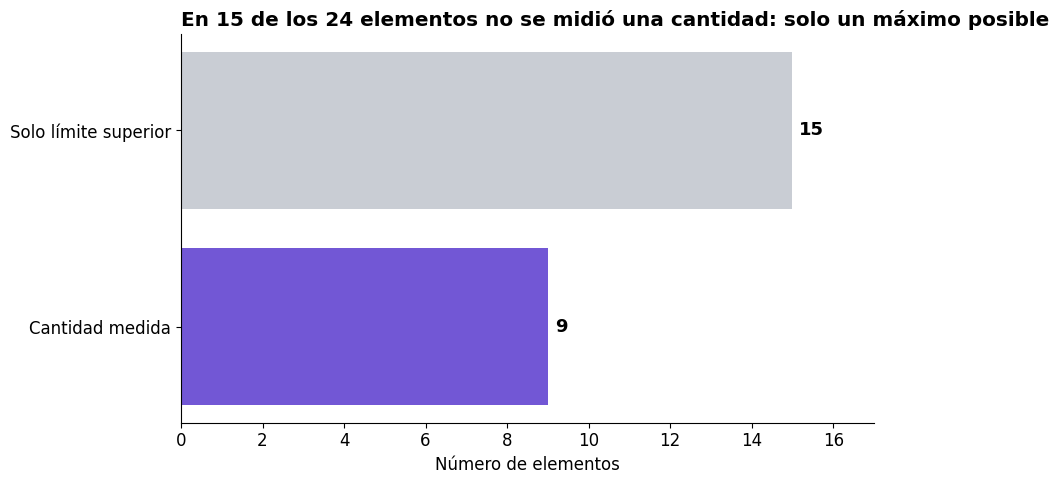

In [4]:
# separo las cantidades medidas de los máximos posibles para no mezclarlos
recuento = pd.Series({
    'Cantidad medida': int((~abundancias.es_limite_superior).sum()),
    'Solo límite superior': int(abundancias.es_limite_superior.sum()),
})

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(recuento.index, recuento.values, color=[color_nebula, color_muted])
ax.set_title('En 15 de los 24 elementos no se midió una cantidad: solo un máximo posible', loc='left')
ax.set_xlabel('Número de elementos')
ax.bar_label(bars, padding=5, fontsize=13, fontweight='bold')
ax.set_xlim(0, 17)
fig.tight_layout()
# guardo la figura con resolución suficiente para reutilizarla en el artículo
fig.savefig(figures_dir / '01_detecciones_y_limites.png', dpi=180, bbox_inches='tight')
plt.show()

## Una pausa: cómo leer una escala logarítmica

Las abundancias se expresan con logaritmos porque las diferencias pueden ser enormes. En esta escala:

- una diferencia de **1** equivale a multiplicar por **10**;
- una diferencia de **2** equivale a multiplicar por **100**;
- una diferencia de **3** equivale a multiplicar por **1.000**.

Por eso una barra que avanza unas pocas unidades puede representar miles de veces más material.

## Pista 2: el niobio rompe el patrón

Para esta comparación conservo solo los elementos detectados que, según los modelos del estudio, no pueden mantenerse en la atmósfera gracias al empuje de la radiación. Si están ahí, debe estar llegando material desde el exterior.

Comparo la abundancia observada con la del Sol. Esto muestra la anomalía en la atmósfera de la estrella, pero todavía no equivale exactamente a la composición del posible planeta: cada elemento se hunde a una velocidad distinta.

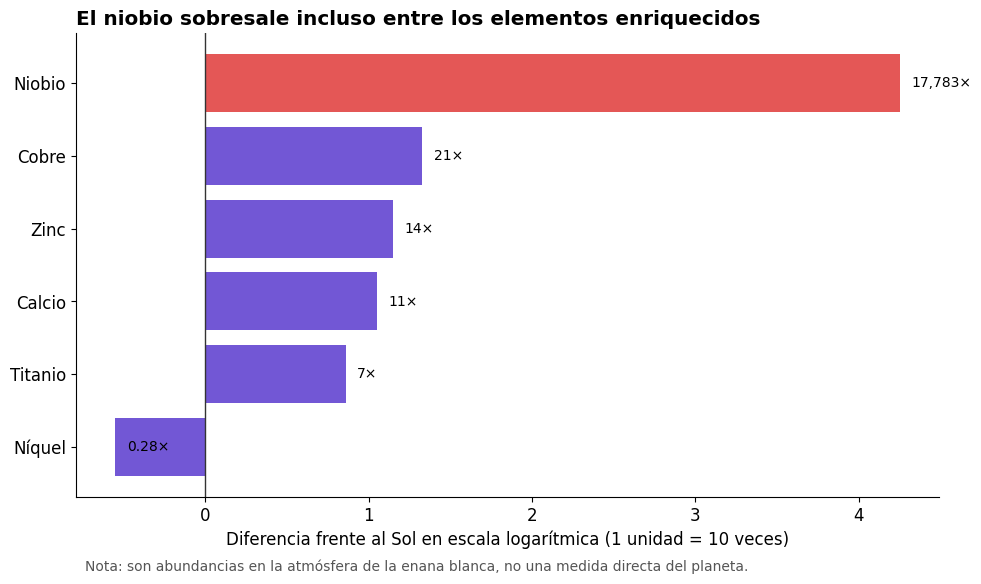

In [5]:
# excluyo los límites y los elementos que la radiación puede mantener suspendidos
comparables = abundancias.loc[
    (~abundancias.es_limite_superior) & (abundancias.afectado_levitacion == False)
].copy()
comparables['diferencia_dex'] = comparables.log_abundancia - comparables.log_abundancia_solar
comparables['factor_frente_sol'] = 10 ** comparables.diferencia_dex
comparables = comparables.sort_values('diferencia_dex')

# traduzco la diferencia logarítmica a un factor que resulte más intuitivo
colors = [color_highlight if s == 'Nb' else color_nebula for s in comparables.simbolo]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(comparables.elemento, comparables.diferencia_dex, color=colors)
ax.axvline(0, color='#333333', linewidth=1)
ax.set_title('El niobio sobresale incluso entre los elementos enriquecidos', loc='left')
ax.set_xlabel('Diferencia frente al Sol en escala logarítmica (1 unidad = 10 veces)')
for bar, factor in zip(bars, comparables.factor_frente_sol):
    x = bar.get_width()
    etiqueta = f'{factor:.2f}×' if factor < 1 else f'{factor:,.0f}×'
    ax.text(x + 0.07, bar.get_y() + bar.get_height()/2, etiqueta, va='center', fontsize=10)
ax.text(0.01, -0.16, 'Nota: son abundancias en la atmósfera de la enana blanca, no una medida directa del planeta.', transform=ax.transAxes, fontsize=10, color='#555555')
fig.tight_layout()
# guardo la comparación que concentra la principal anomalía química
fig.savefig(figures_dir / '02_anomalia_niobio.png', dpi=180, bbox_inches='tight')
plt.show()

### Qué acabo de ver

El niobio no destaca por una diferencia pequeña. Su abundancia atmosférica relativa al hidrógeno está más de cuatro unidades logarítmicas por encima de la referencia solar: una diferencia de decenas de miles de veces.

El estudio no basa la identificación en una sola marca dudosa. Atribuye al niobio **62 líneas espectrales**: cinco de Nb III y 57 de Nb IV. Los números romanos indican cuántos electrones ha perdido el átomo; no representan dos elementos diferentes.

## Pista 3: 33 comparaciones y ninguna detección de niobio

Una cantidad extraña solo puede llamarse anómala si existe algo con lo que compararla. El equipo revisó espectros de 33 enanas blancas calientes y enriquecidas con metales. En ninguna confirmó niobio.

Esto no significa que la probabilidad sea exactamente 1 entre 34. La muestra no es un sorteo aleatorio de todas las enanas blancas del universo. El resultado solo establece que HS 0209+0832 es única dentro de la comparación examinada.

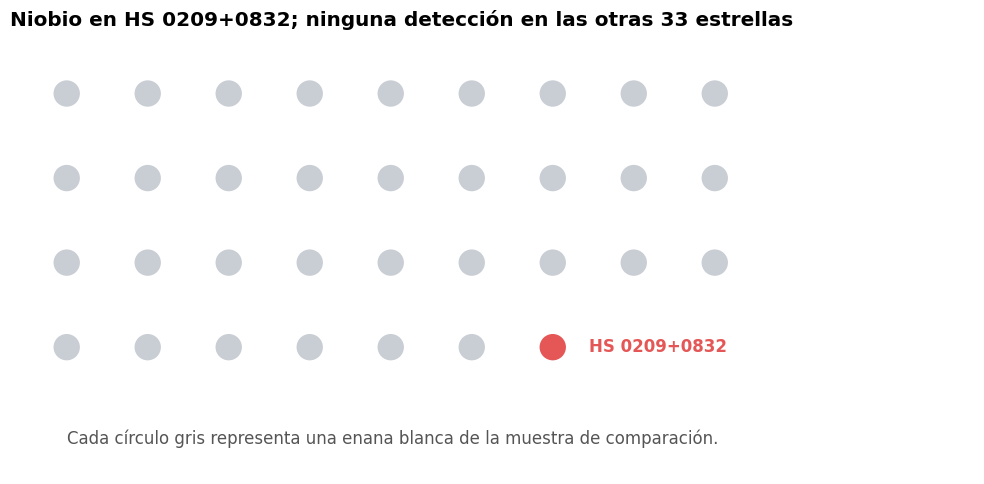

In [6]:
# represento cada estrella como un punto para hacer visible el tamaño de la comparación
n_comparacion = 33
x = np.arange(n_comparacion + 1) % 9
y = -(np.arange(n_comparacion + 1) // 9)
colors = [color_muted] * n_comparacion + [color_highlight]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, s=420, color=colors, edgecolor='white', linewidth=1.5)
ax.text(x[-1] + 0.45, y[-1], 'HS 0209+0832', va='center', fontweight='bold', color=color_highlight)
ax.set_title('Niobio en HS 0209+0832; ninguna detección en las otras 33 estrellas', loc='left')
ax.text(0, -4.15, 'Cada círculo gris representa una enana blanca de la muestra de comparación.', color='#555555')
ax.set_xlim(-0.7, 11.2)
ax.set_ylim(-4.5, 0.7)
ax.axis('off')
fig.tight_layout()
# guardo la figura sin convertir el recuento en una probabilidad que los datos no permiten
fig.savefig(figures_dir / '03_comparacion_33_enanas_blancas.png', dpi=180, bbox_inches='tight')
plt.show()

## Pista 4: el hierro ausente también cuenta una historia

Los planetas rocosos conocidos contienen mucho hierro y silicio. En HS 0209+0832 se detecta muy poco silicio y no se detecta hierro, pero sí níquel.

Como el hierro solo tiene un límite superior, no conozco la proporción exacta. Sí puedo calcular un mínimo: hay al menos unas dos veces más átomos de níquel que de hierro. En el Sol ocurre lo contrario: por cada átomo de níquel hay aproximadamente 17 de hierro.

In [7]:
# recupero las dos filas que necesito para calcular el cociente mínimo
ni = abundancias.set_index('simbolo').loc['Ni']
fe = abundancias.set_index('simbolo').loc['Fe']

# uso el límite del hierro para obtener un mínimo, no una proporción exacta
minimo_ni_fe = 10 ** (ni.log_abundancia - fe.log_abundancia)
solar_ni_fe = 10 ** (ni.log_abundancia_solar - fe.log_abundancia_solar)

pd.DataFrame({
    'Comparación': ['HS 0209+0832', 'Sol'],
    'Níquel por cada átomo de hierro': [f'más de {minimo_ni_fe:.2f}', f'{solar_ni_fe:.2f}'],
})

,Comparación,Níquel por cada átomo de hierro
0,HS 0209+0832,más de 2.09
1,Sol,0.06


## La segunda clase de pista: una variación diminuta en el brillo

El satélite TESS midió el brillo de la estrella durante cuatro periodos de observación. Al combinar los datos, los investigadores encontraron una variación que se repite cada **4,399 ± 0,026 días**.

La amplitud es de solo **0,120 ± 0,018 %**. Dicho de otra forma: si el brillo normal fueran 1.000 unidades, el cambio sería de aproximadamente 1,2 unidades.

No se observó un tránsito claro del planeta por delante de la estrella. La periodicidad puede estar relacionada con la cara caliente de un planeta, con una cola de gas evaporado o con algún fenómeno de la propia estrella. Por eso es una pista de apoyo, no una fotografía del planeta.

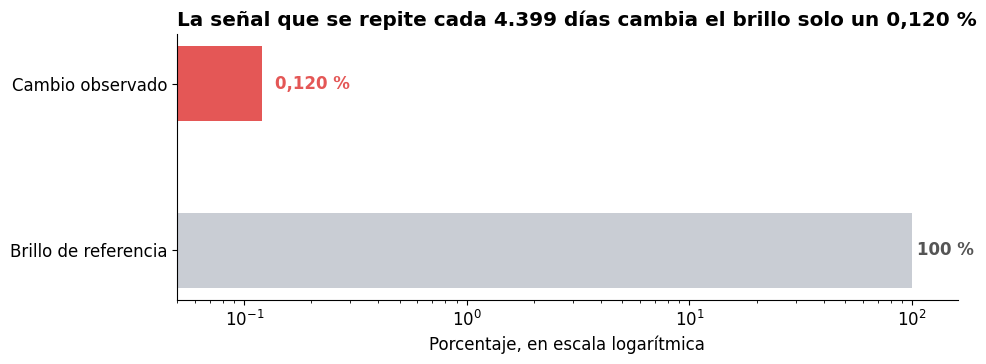

In [8]:
# extraigo el periodo y la amplitud publicados sin volver a estimarlos
amplitud = float(evidencias.loc[evidencias.evidencia == 'Amplitud fotométrica', 'valor'].iloc[0])
periodo = float(evidencias.loc[evidencias.evidencia == 'Periodo fotométrico', 'valor'].iloc[0])

fig, ax = plt.subplots(figsize=(10, 3.8))
# uso una escala logarítmica para que el cambio diminuto siga siendo visible
ax.barh(['Brillo de referencia'], [100], color=color_muted, height=0.45)
ax.barh(['Cambio observado'], [amplitud], color=color_highlight, height=0.45)
ax.set_xscale('log')
ax.set_xlim(0.05, 160)
ax.set_xlabel('Porcentaje, en escala logarítmica')
ax.set_title(f'La señal que se repite cada {periodo:.3f} días cambia el brillo solo un 0,120 %', loc='left')
ax.text(amplitud * 1.15, 1, '0,120 %', va='center', color=color_highlight, fontweight='bold')
ax.text(105, 0, '100 %', va='center', color='#555555', fontweight='bold')
fig.tight_layout()
# guardo la figura como apoyo visual para explicar la escala de la señal
fig.savefig(figures_dir / '04_escala_variacion_brillo.png', dpi=180, bbox_inches='tight')
plt.show()

## La cadena completa de evidencia

| Nivel | Resultado | Qué permite decir |
|---|---|---|
| **Observación** | Hay carbono, calcio, titanio, níquel, cobre, zinc y niobio en la atmósfera. | Está cayendo material externo sobre la enana blanca. |
| **Observación** | El niobio deja 62 líneas identificadas y no aparece en las 33 estrellas comparadas. | La composición es extraordinaria dentro de la muestra examinada. |
| **Observación** | El brillo presenta una periodicidad de 4,399 días. | Existe un fenómeno estable que se repite, aunque su origen no se ve directamente. |
| **Interpretación** | El exceso de elementos producidos al final de la vida de una estrella encaja con material de segunda generación. | Un planeta formado con materia expulsada por la estrella explica conjuntamente varias pistas. |
| **Hipótesis abierta** | La variación de brillo podría proceder de un planeta caliente o de gas que se evapora. | Hacen falta observaciones adicionales para confirmar el objeto y conocer su naturaleza. |

## Qué puedo afirmar, qué no puedo afirmar y por qué importa

### Lo que puedo afirmar

HS 0209+0832 está recibiendo material con una composición que no se parece a los restos rocosos habituales. El niobio es la anomalía más llamativa y la estrella presenta además una variación periódica de brillo.

### Lo que todavía no puedo afirmar

El planeta no ha sido observado directamente. Tampoco puedo determinar si se formó por completo después de la muerte de la estrella o si un planeta anterior sobrevivió y adquirió una nueva envoltura. Algunos detalles químicos, como la ausencia de estroncio, tampoco encajan perfectamente con los modelos actuales.

### La conclusión del EDA

Los datos no permiten escribir que una estrella muerta «ha dado a luz un planeta» como un hecho cerrado. Sí permiten afirmar algo más preciso: **HS 0209+0832 reúne una combinación excepcional de pistas químicas y fotométricas compatible con un candidato a planeta de segunda generación**.

La fuerza de la historia no está en una prueba definitiva, sino en cómo varias anomalías independientes construyen una explicación coherente.

## Limitaciones de esta primera versión

- Utiliza las medidas publicadas por los autores, no una reducción independiente de los espectros.
- La comparación de 33 estrellas se resume con el resultado agregado publicado; todavía no incorpora una tabla individual de esa muestra.
- La curva de luz de TESS aún no se ha descargado y reprocesado dentro del proyecto.
- Comparar abundancias atmosféricas con las solares sirve para visualizar la anomalía, pero reconstruir la composición del material requiere corregir la velocidad de hundimiento de cada elemento.

Estas limitaciones no invalidan el EDA: delimitan con claridad qué parte del hallazgo reproduzco y qué parte depende del análisis especializado del equipo científico.

## Fuentes

- Williams, J. T. et al. (2026). *Discovery of a second-generation planet candidate accreting onto a white dwarf*. Nature Astronomy. https://doi.org/10.1038/s41550-026-02983-7
- Prepublicación y fuente del manuscrito: https://arxiv.org/abs/2610.07161

Fecha de consulta y preparación del EDA: 9 de octubre de 2026.